In [320]:
import pandas as pd
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTETomek
from sklearn.metrics import recall_score, f1_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [321]:
data_path = "sleep_doomscrolling_habits.csv"

df = pd.read_csv(data_path)

df.head(10)

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair
5,D30005,21,81.0,5.20,4,19.5,7.9,39.0,2,61.0,...,Student,Nigeria,Smartphone,Watching Videos,No,Yes,No,No,Yes,Fair
6,D30006,34,56.0,3.75,3,18.7,8.8,45.0,1,166.0,...,Employed Full-time,Philippines,Smartphone,Scrolling Social Media,No,Yes,No,No,Yes,Good
7,D30007,26,40.0,2.41,3,13.7,7.7,36.0,2,54.0,...,Student,United Kingdom,Smartphone,Scrolling Social Media,Yes,Yes,Yes,Yes,Yes,Poor
8,D30008,32,77.0,3.38,4,19.2,7.8,29.0,1,127.0,...,Employed Full-time,Germany,Smartphone,Reading,Yes,Yes,No,No,Yes,Fair
9,D30009,34,23.0,2.46,2,7.8,6.4,18.0,3,97.0,...,Employed Full-time,Philippines,Tablet,Reading,No,No,No,No,No,Poor


In [322]:
# Reading null data
print(f"Missing Values : {df.isnull().sum()}")

Missing Values : respondent_id                      0
age                                0
bedtime_screen_time_minutes        0
total_daily_screen_time_hours      0
doomscroll_sessions_per_night      0
avg_doomscroll_session_minutes     0
sleep_hours_per_night              0
sleep_latency_minutes              0
number_of_night_wakeups            0
caffeine_intake_mg_per_day        50
anxiety_score                      0
stress_score                       0
sleep_quality_score               40
daytime_fatigue_score              0
number_of_news_apps_used           0
phone_checks_per_night             0
exercise_minutes_per_day          50
days_since_last_digital_detox      0
weekly_sleep_debt_hours            0
gender                             0
occupation_status                 30
country_region                     0
primary_device_used_at_night      30
bedtime_routine_type              20
uses_night_mode                    0
keeps_phone_in_bedroom             0
consumes_negative_new

In [323]:
print(df['sleep_quality_category'].unique())

<StringArray>
['Good', 'Poor', 'Fair']
Length: 3, dtype: str


In [324]:
dfe = df.copy()

dfe = dfe.drop(['respondent_id'], axis=1)

cat_cols = ['caffeine_intake_mg_per_day', 'sleep_quality_score', 'exercise_minutes_per_day', 'occupation_status', 'primary_device_used_at_night', 'bedtime_routine_type']  

cat_imputer = SimpleImputer(strategy='most_frequent')
dfe[cat_cols] = cat_imputer.fit_transform(dfe[cat_cols])

print(f"Missing Values : {dfe.isnull().sum().max()}")

Missing Values : 0


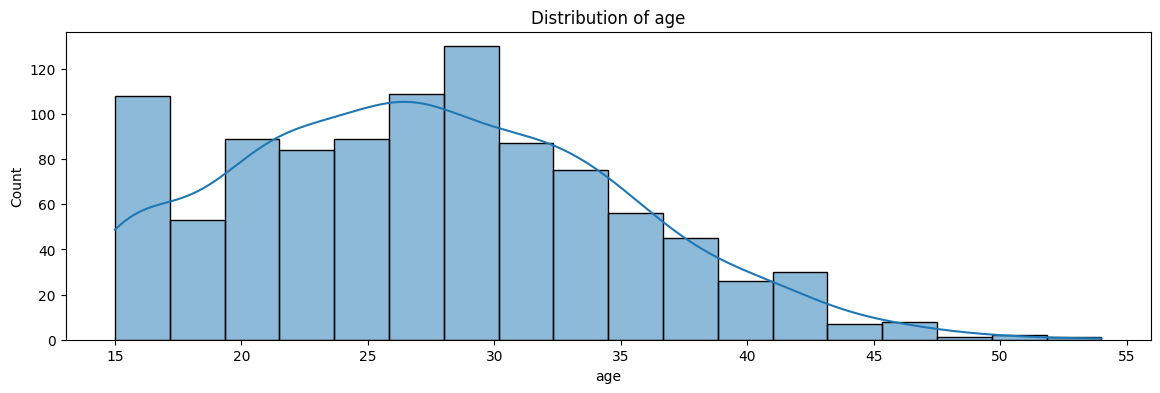

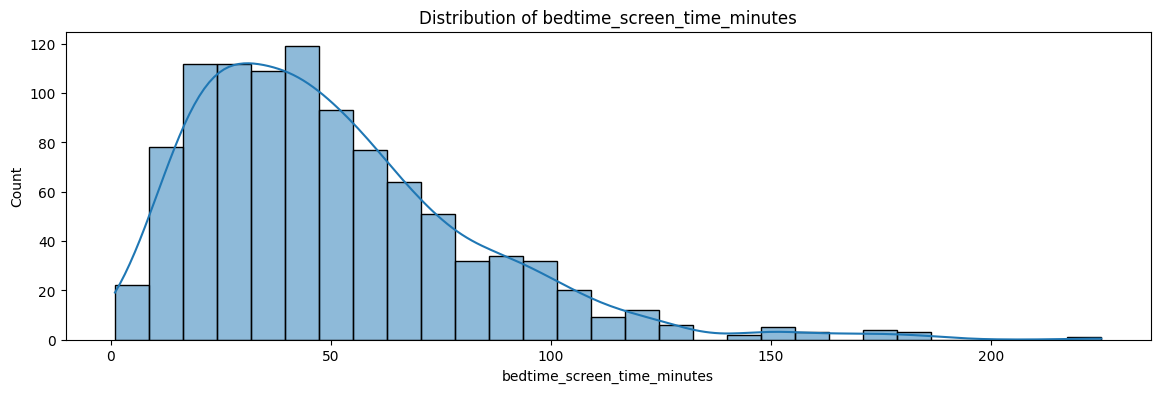

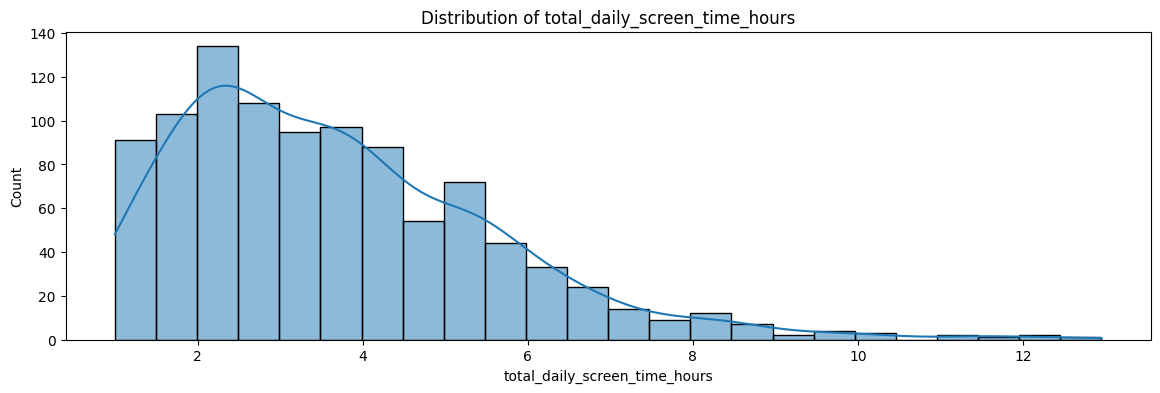

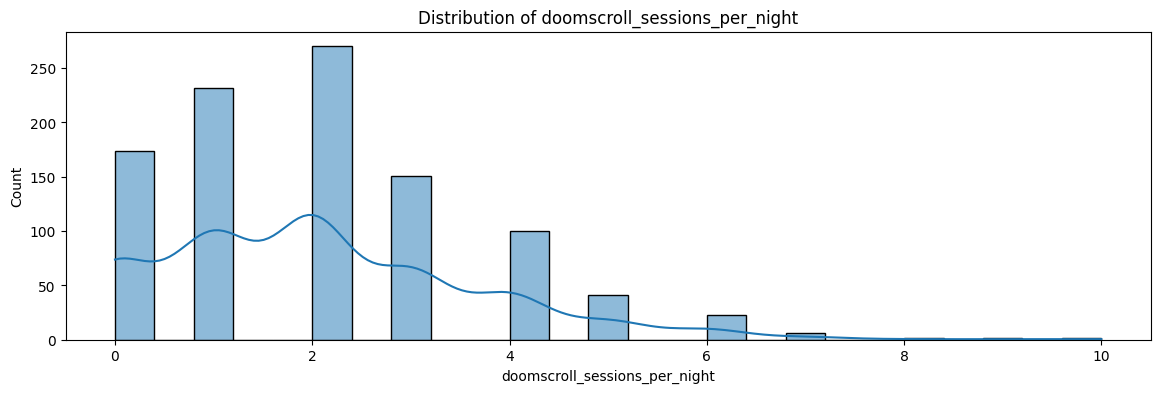

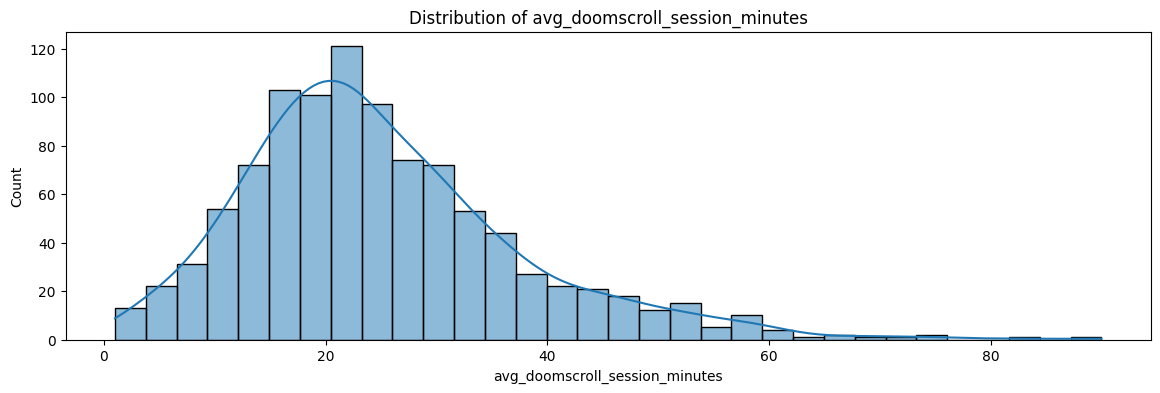

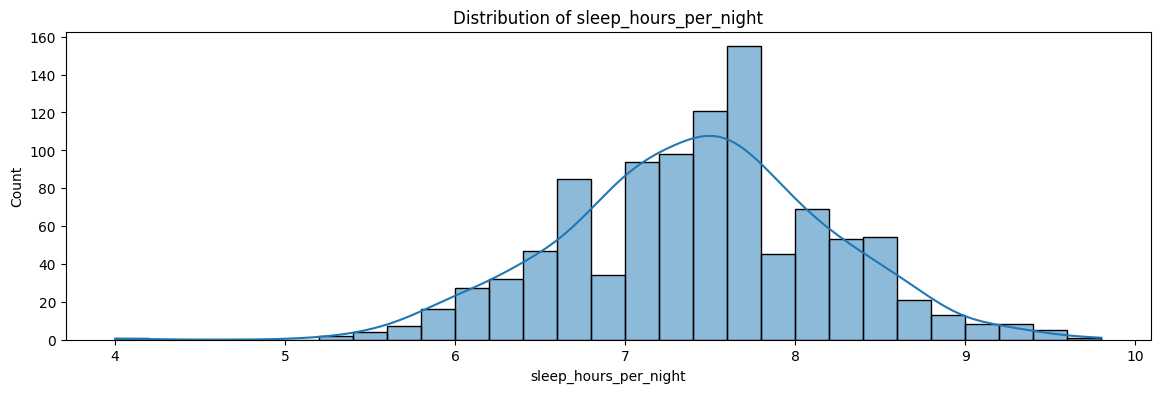

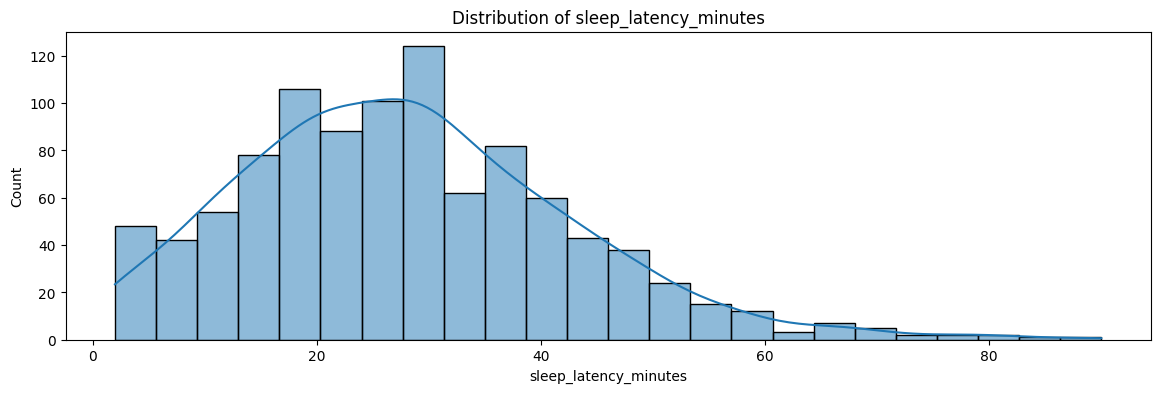

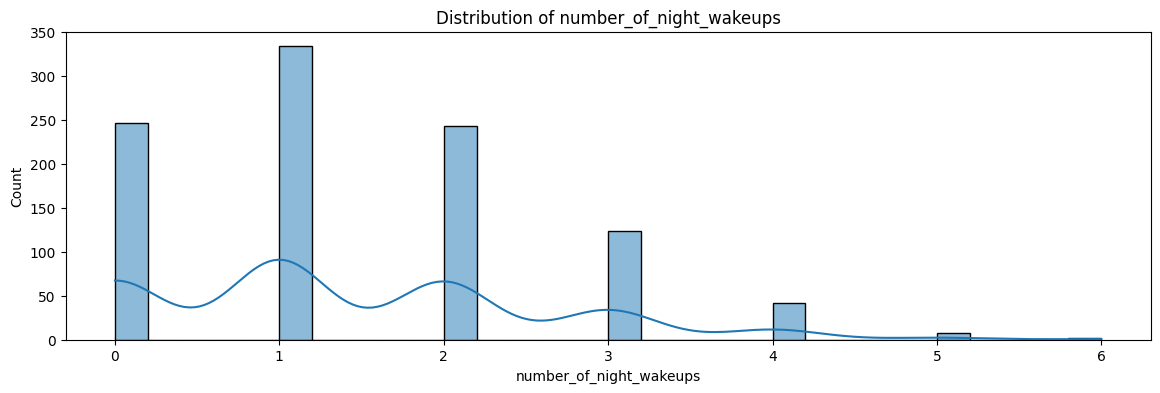

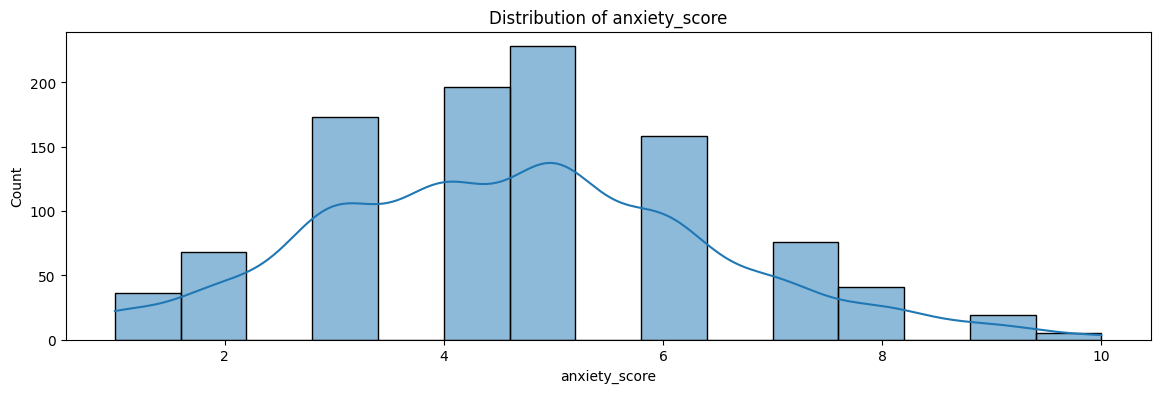

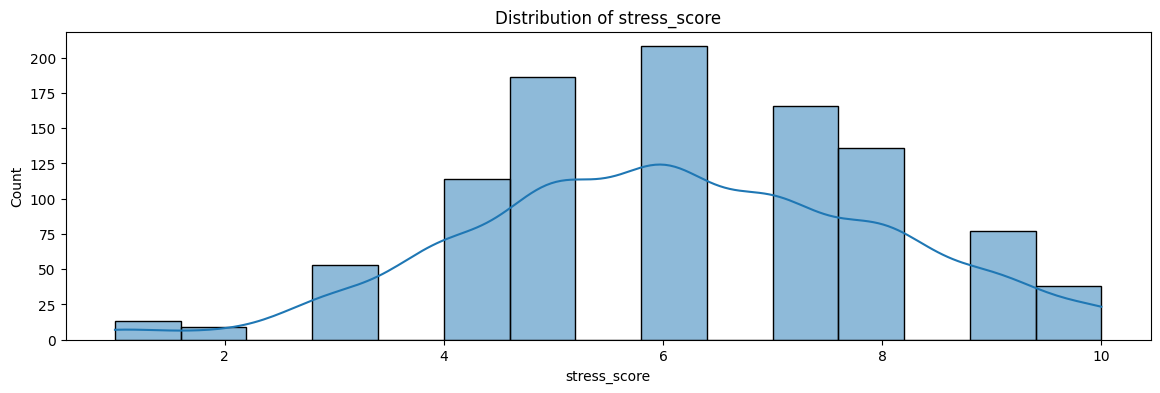

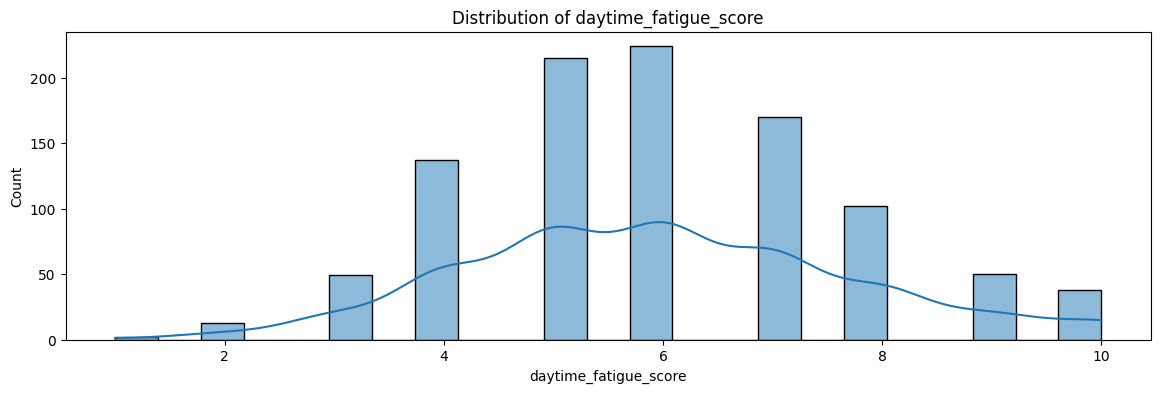

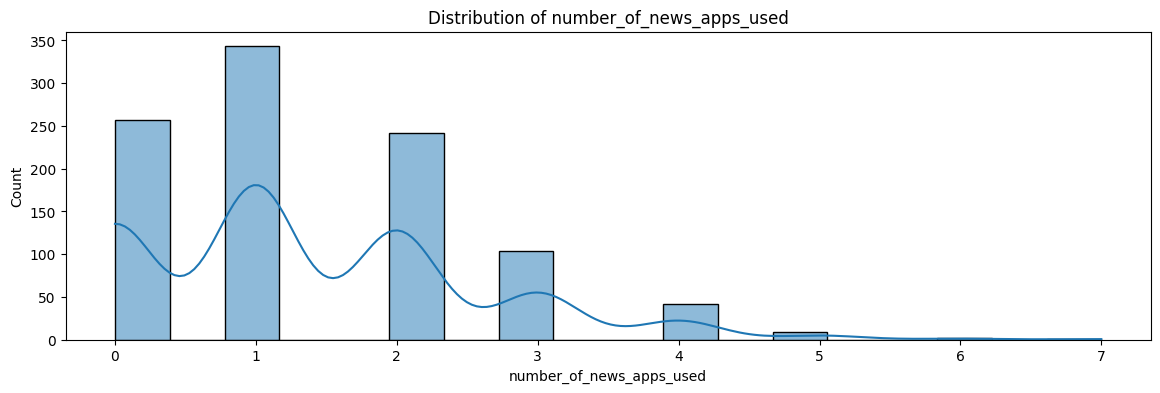

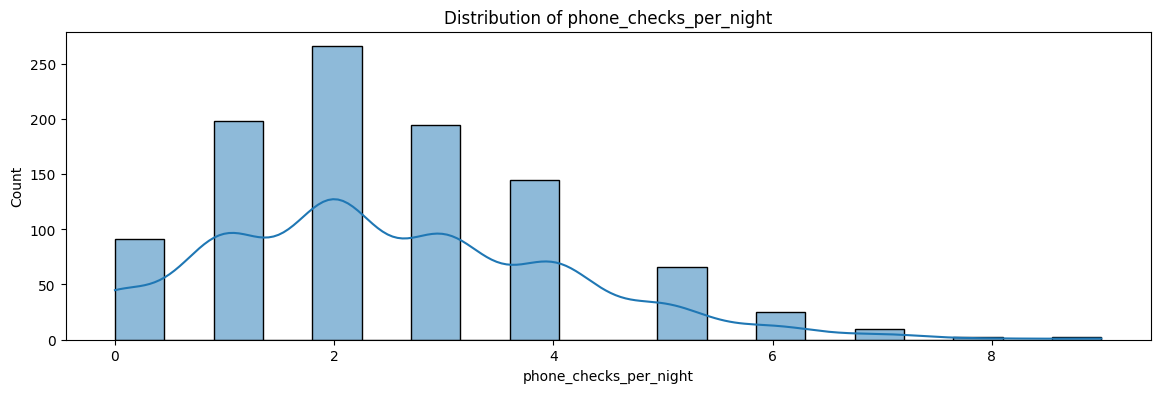

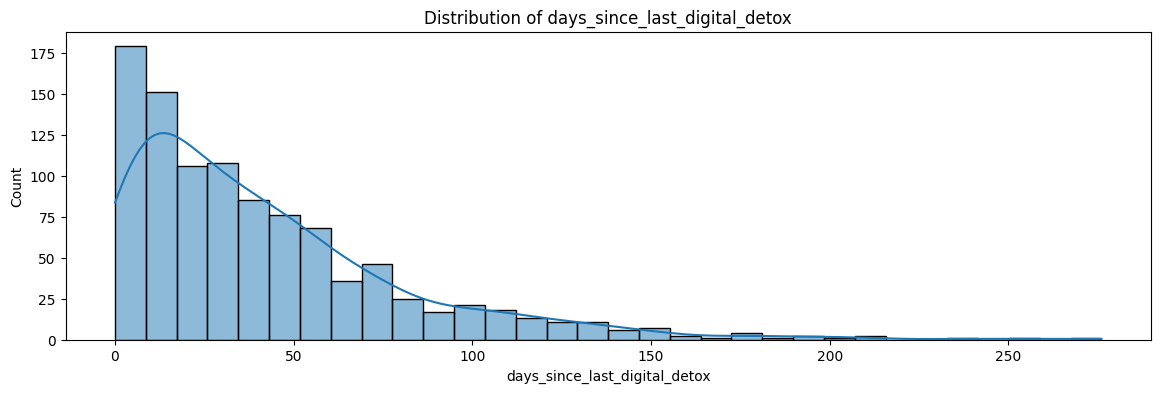

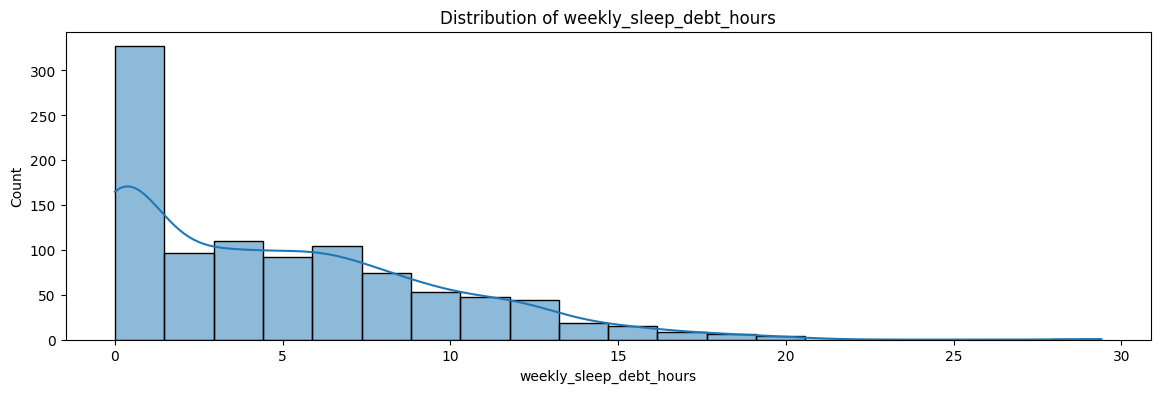

In [325]:
# EDA Data visualization for types of number

num_cols=dfe.select_dtypes(include='number')
for col in num_cols[:10]:
    plt.figure(figsize=(14,4))
    sns.histplot(dfe[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    

In [326]:
print(dfe.select_dtypes(include=['str']).sum())

gender                            MaleMalePrefer not to sayPrefer not to sayPref...
occupation_status                 UnemployedStudentStudentEmployed Full-timeEmpl...
country_region                    GermanyIndiaIndiaUnited StatesUnited StatesNig...
primary_device_used_at_night      TabletSmartphoneLaptopSmartphoneSmartphoneSmar...
bedtime_routine_type              Meditation/JournalingMeditation/JournalingRead...
uses_night_mode                   YesNoNoNoNoNoNoYesYesNoYesYesYesNoNoNoNoNoYesY...
keeps_phone_in_bedroom            YesYesYesYesNoYesYesYesYesNoYesNoYesNoYesYesYe...
consumes_negative_news_content    YesYesNoYesNoNoNoYesNoNoNoNoNoYesYesNoNoYesNoY...
uses_sleep_tracking_app           NoNoYesNoNoNoNoYesNoNoYesYesNoNoNoNoNoNoNoYesN...
doomscroller                      YesYesYesNoNoYesYesYesYesNoNoNoNoNoNoYesNoNoNo...
sleep_quality_category            GoodPoorFairFairFairFairGoodPoorFairPoorPoorGo...
dtype: str


In [327]:
binary_cols = [
    'uses_night_mode', 'keeps_phone_in_bedroom',
    'consumes_negative_news_content', 'uses_sleep_tracking_app',
    'doomscroller'
]

for col in binary_cols:
    dfe[col] = dfe[col].map({"Yes" : 1, "No" : 0})

dfe['sleep_quality_category'] = dfe['sleep_quality_category'].map({'Poor': 0, 'Fair': 1, 'Good': 2})

print(f"Country region : {dfe['country_region'].nunique()}")

ohe = ['gender', 'occupation_status', 
            'primary_device_used_at_night', 'bedtime_routine_type']

if dfe['country_region'].nunique() < 20:
    ohe.append('country_region')
else:
    dfe = dfe.drop('country_region', axis=1)
    print("country_region dropped — too many unique values")

dfe = pd.get_dummies(dfe, columns=ohe, dtype=int)

print(dfe.select_dtypes(include=['str', 'object']).columns.tolist())
print(dfe.shape)


Country region : 10
['caffeine_intake_mg_per_day', 'sleep_quality_score', 'exercise_minutes_per_day']
(1000, 50)


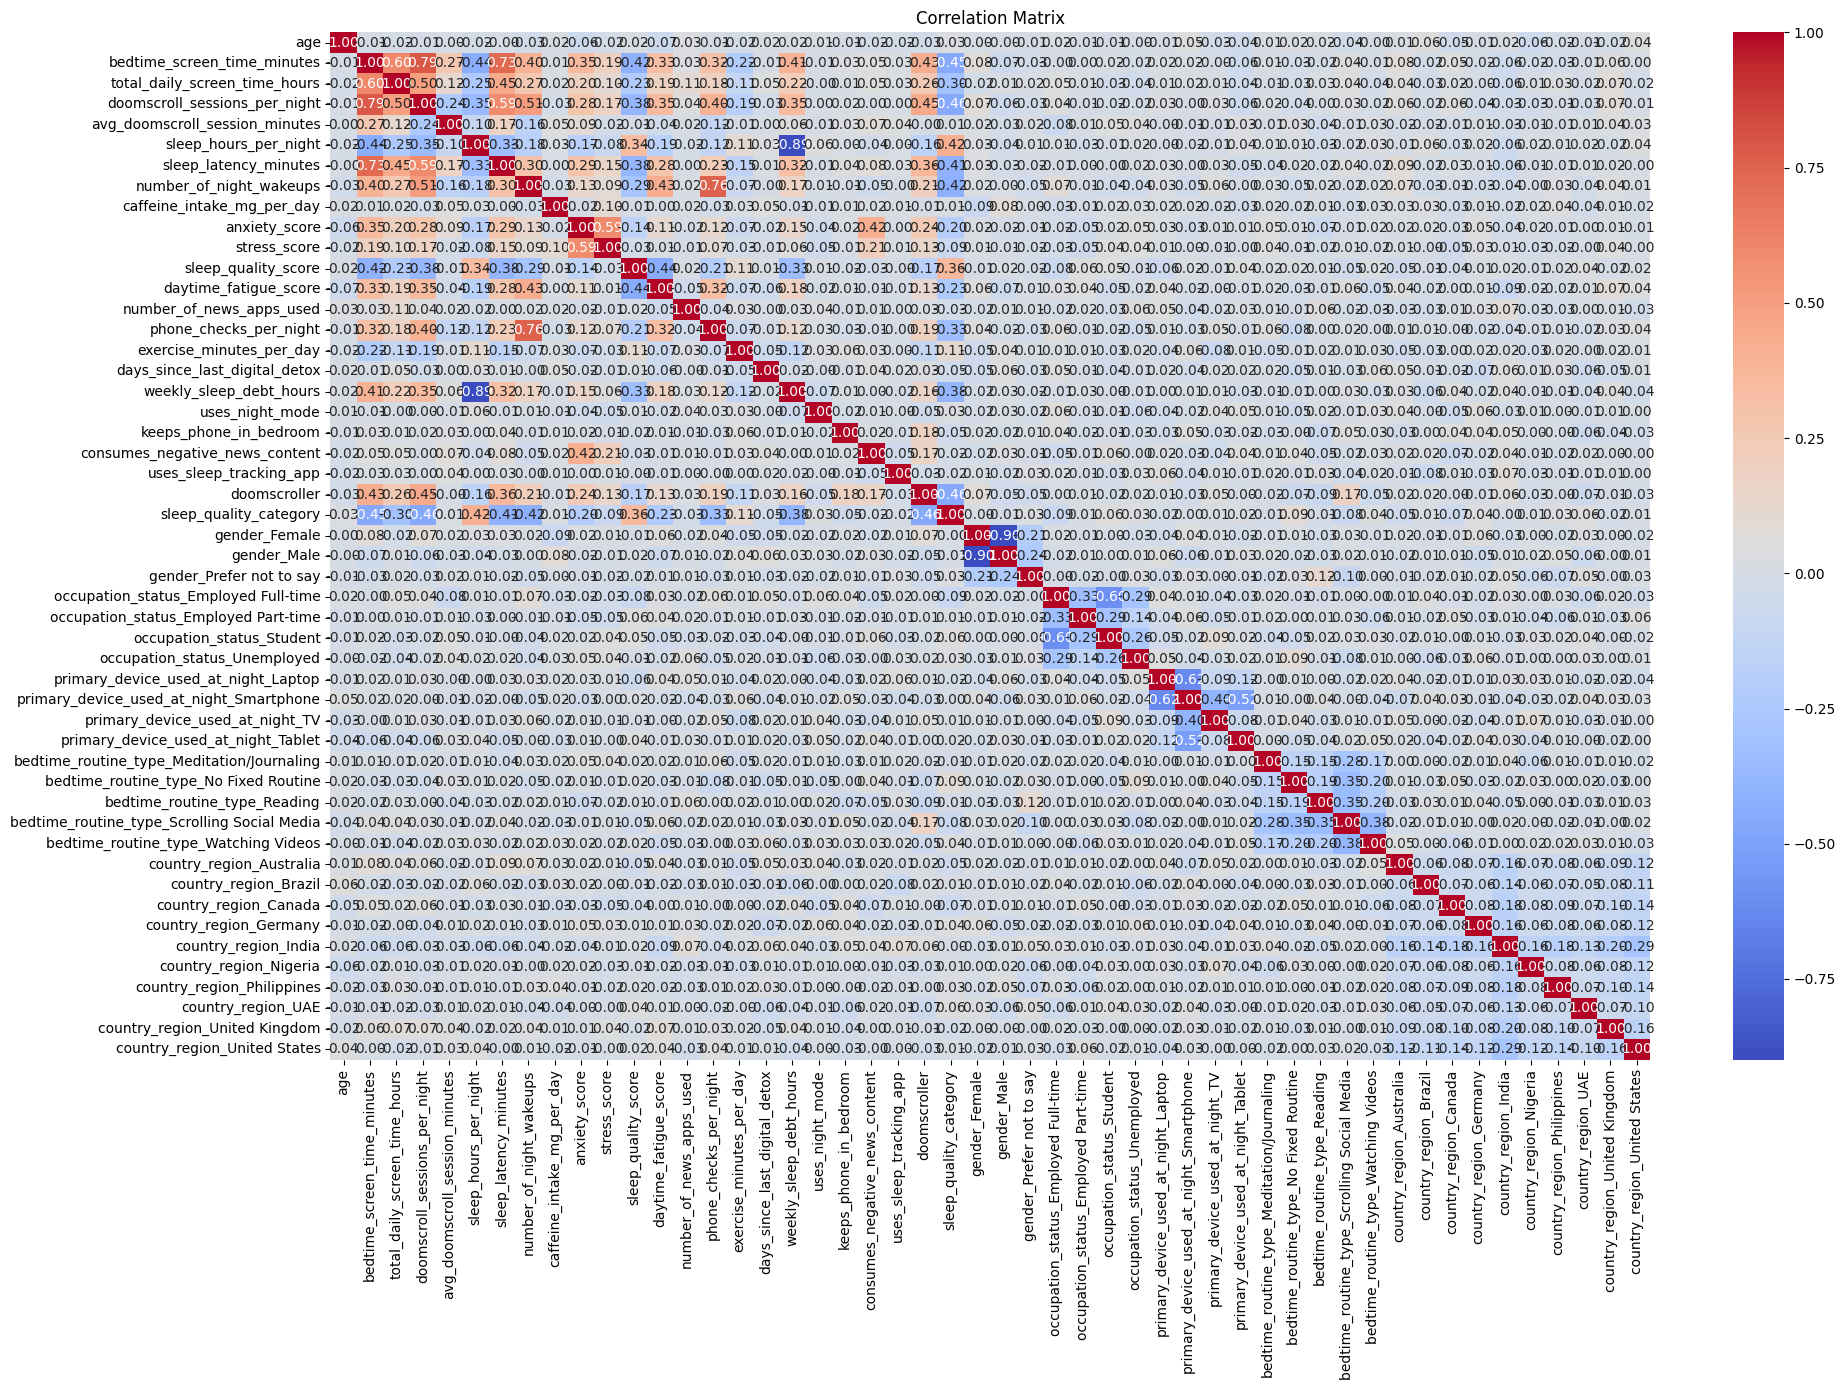

In [328]:
# Heatmap Seaborn

plt.figure(figsize=(20,14))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

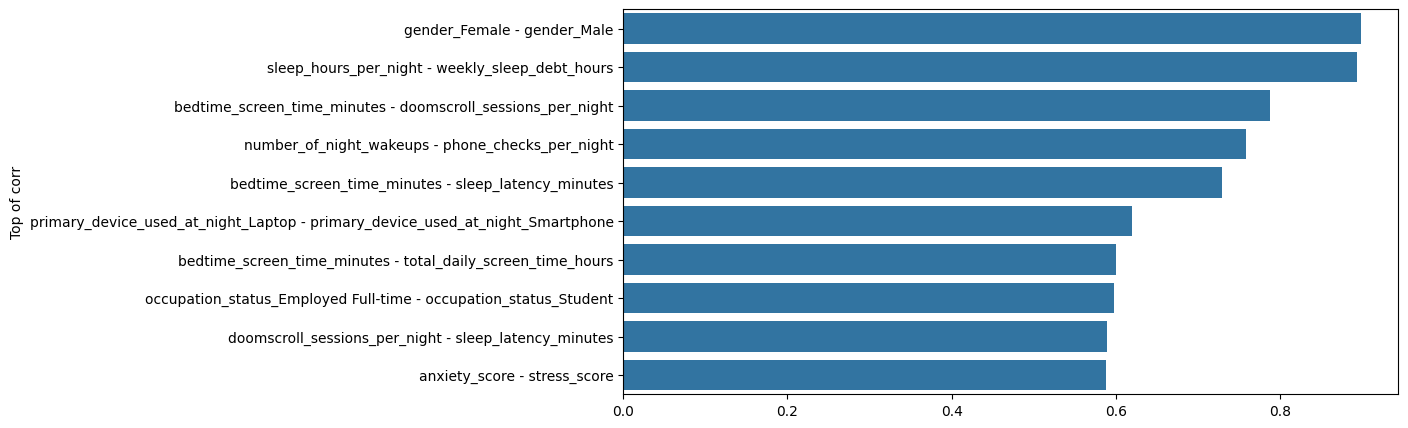

In [329]:
# Feature comparison visual data

corr_matrix = dfe.corr().abs()
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


In [330]:
X = dfe.drop(['sleep_quality_category'], axis=1)

y = dfe['sleep_quality_category']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, )

print("X Train size", len(y_train))
print("Y Test size", len(y_valid))


print("\nLabel test count data")
print(y_valid.value_counts())
print(X_train.shape)
print("Length of data", len(y_valid))

X Train size 700
Y Test size 300

Label test count data
sleep_quality_category
0    106
1     98
2     96
Name: count, dtype: int64
(700, 49)
Length of data 300


In [331]:
print(f"Data before rebalancing {len(y_train)}")

smote = SMOTETomek(random_state=2)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Data After rebalancing : {len(y_train_smote)}")

Data before rebalancing 700
Data After rebalancing : 540


Time predict : 0.07910691600045539 seconds


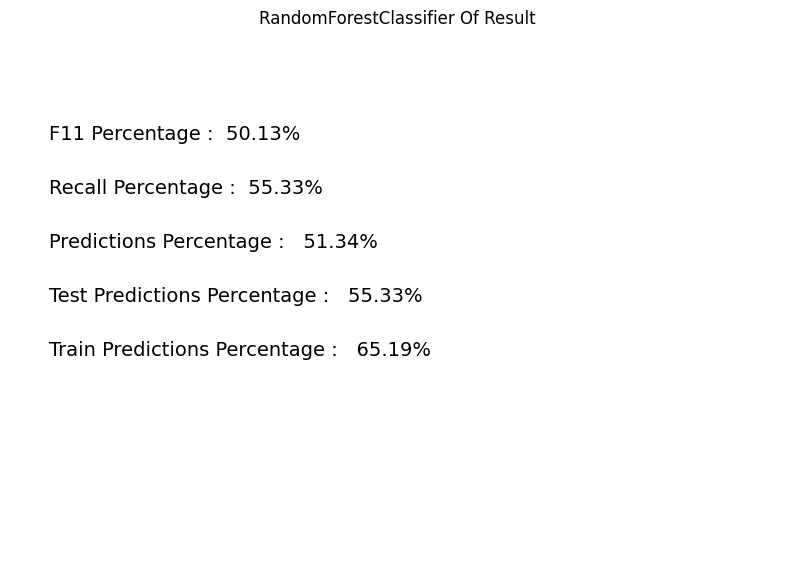

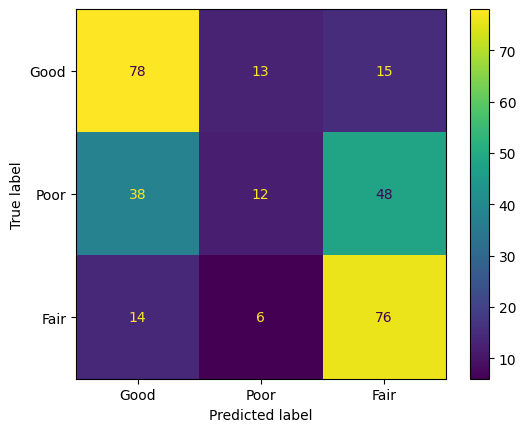


Calculating Learning Curve...


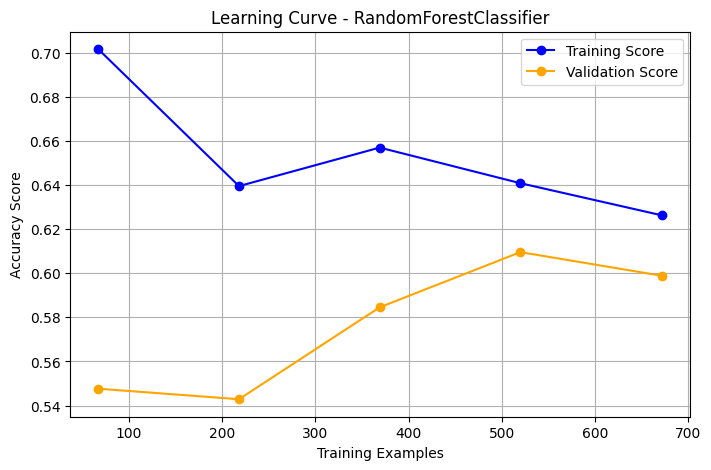

In [332]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

model_rfc = RandomForestClassifier(    
    n_estimators=100,      
    max_depth=2,           
    min_samples_split=10,   
    min_samples_leaf=10,    
    random_state=42,
)

model_rfc.fit(X_train_smote, y_train_smote)

train_predictions = model_rfc.predict(X_train_smote)
test_predictions = model_rfc.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good", "Poor", "Fair"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Time predict : 0.013223374999142834 seconds


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


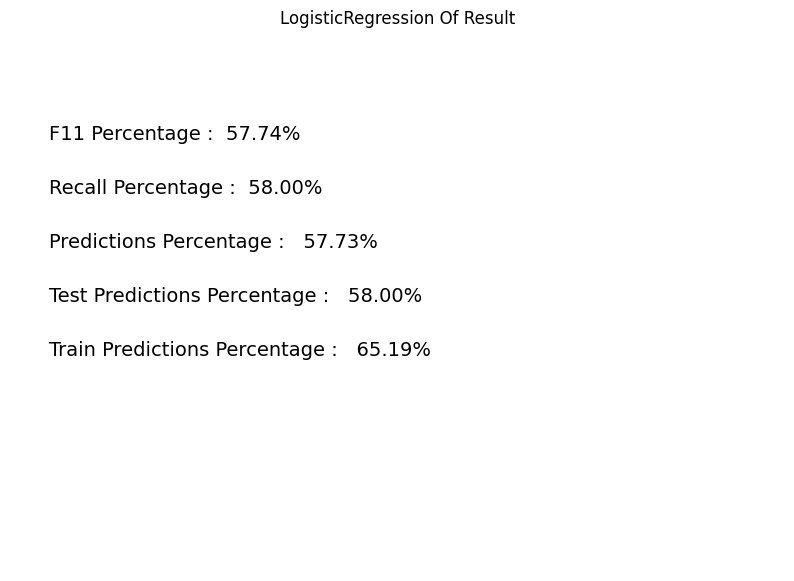

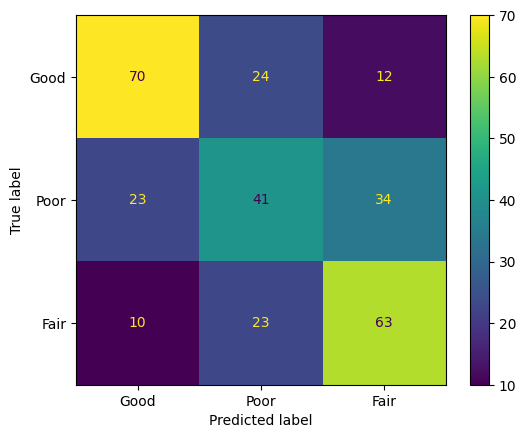


Calculating Learning Curve...


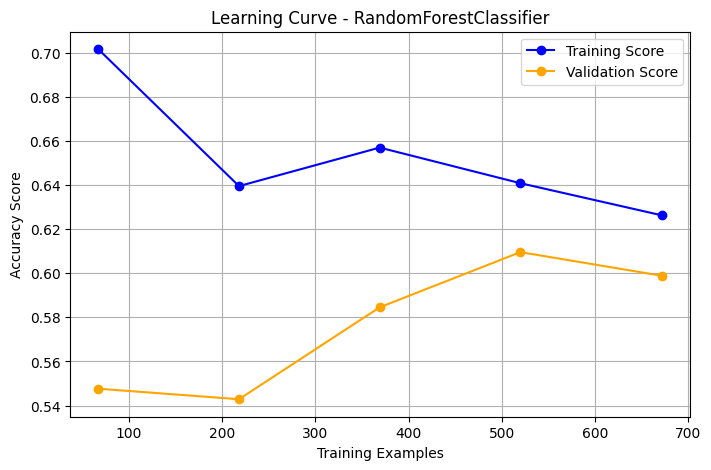

In [333]:
# Classifier using LogisticRegression

time_start = time.perf_counter()

model_lgr = LogisticRegression(    
    C=0.8,
    class_weight='balanced',  
    random_state=42
    )

model_lgr.fit(X_train_smote, y_train_smote)

train_predictions = model_lgr.predict(X_train_smote)
test_predictions = model_lgr.predict(X_valid)

# Evaluate
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Predictions = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions,)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("LogisticRegression Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Poor', 'Fair']).plot()

plt.show()

print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()